#Spanish Wine Quality Classification Problem

Importing the Dataset

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

#Mount Google Drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
df = pd.read_csv('/content/drive/MyDrive/Seep 2025/wines_SPA.csv')
df
df_copy=df.copy()

In [7]:
print(df.isnull().sum())
print(df.duplicated().sum())

winery            0
wine              0
year              2
rating            0
num_reviews       0
country           0
region            0
price             0
type            545
body           1169
acidity        1169
dtype: int64
5452


#Handling Missing Data and Duplicate entries

In [8]:
df.drop(columns=['country'],inplace=True)
df = df.drop_duplicates()
df['body'] = df['body'].fillna(df['body'].median())
df['acidity'] = df['acidity'].fillna(df['acidity'].median())
df['type'] = df['type'].fillna(df['type'].mode()[0])

In [9]:
df = df.dropna(subset=['year'])
# standardizing string columns
str_cols = df.select_dtypes(include='object').columns
df[str_cols] = df[str_cols].apply(lambda col: col.str.strip())
# Drop unhelpful columns
df.drop(columns=['winery', 'wine'], inplace=True)

# Clean and use year
df['year'] = pd.to_numeric(df['year'], errors='coerce')
df['year'].fillna(df['year'].median(), inplace=True)
df['wine_age'] = 2025 - df['year']

df = df.drop_duplicates()


print(df.duplicated().sum())

print(df.isnull().sum())
print(df.duplicated().sum())

0
year           0
rating         0
num_reviews    0
region         0
price          0
type           0
body           0
acidity        0
wine_age       0
dtype: int64
0


<ipython-input-9-2414083304>:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['year'].fillna(df['year'].median(), inplace=True)


#Outlier Handling

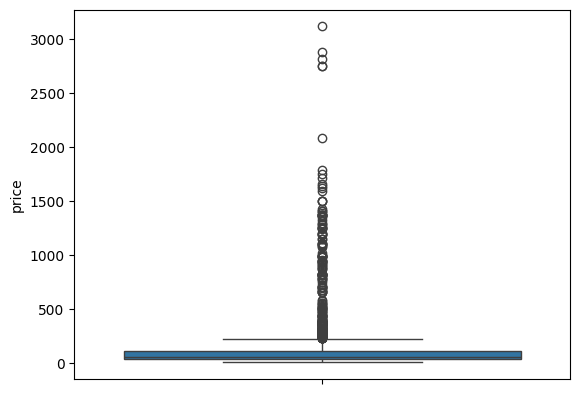

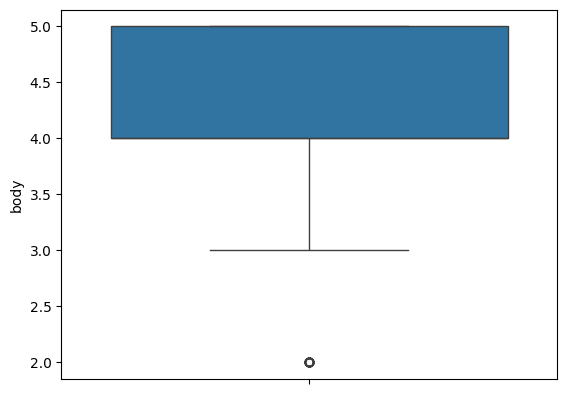

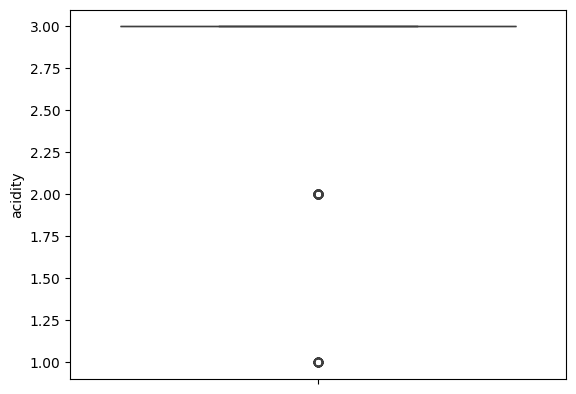

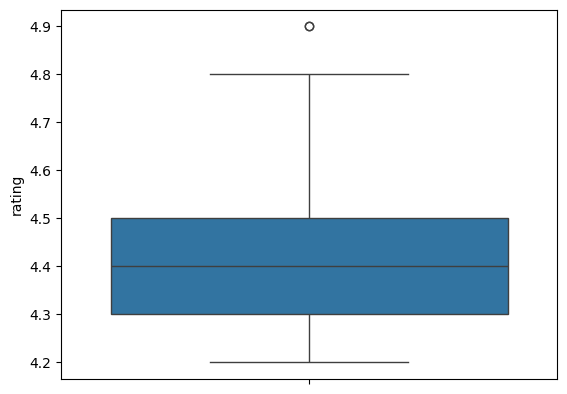

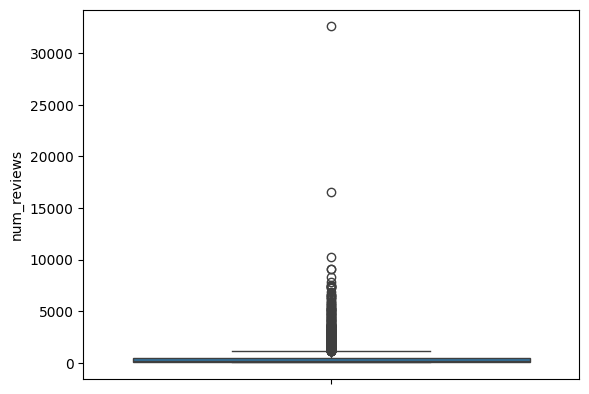

In [10]:
sns.boxplot(df['price'])
plt.show()
sns.boxplot(df['body'])
plt.show()
sns.boxplot(df['acidity'])
plt.show()
sns.boxplot(df['rating'])
plt.show()
sns.boxplot(df['num_reviews'])
plt.show()

<Axes: ylabel='price'>

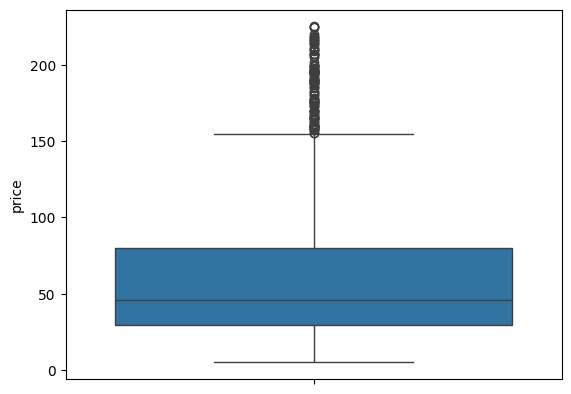

In [11]:
df1=df.copy()
Q1 = df1['price'].quantile(0.25)
Q3 = df1['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df2 = df1[(df1['price'] >= lower_bound) & (df1['price'] <= upper_bound)]
sns.boxplot(df2['price'])

<ipython-input-12-2424203878>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['log_price'] = np.log1p(df2['price'])          # log(1 + price)


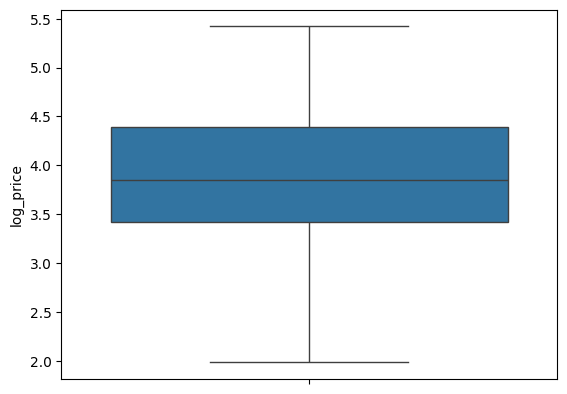

In [12]:
df2['log_price'] = np.log1p(df2['price'])          # log(1 + price)

Q1 = df2['log_price'].quantile(0.25)
Q3 = df2['log_price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df3 = df2[(df2['log_price'] >= lower_bound) & (df2['log_price'] <= upper_bound)]
sns.boxplot(df3['log_price'])
plt.show()

<ipython-input-13-3270997820>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['log_reviews'] = np.log1p(df3['num_reviews'])  # log(1 + reviews)


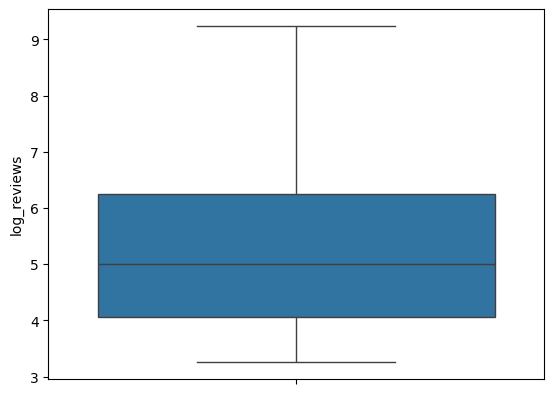

In [13]:
df3['log_reviews'] = np.log1p(df3['num_reviews'])  # log(1 + reviews)
Q1 = df3['log_reviews'].quantile(0.25)
Q3 = df3['log_reviews'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df3 = df3[(df3['log_reviews'] >= lower_bound) & (df3['log_reviews'] <= upper_bound)]
sns.boxplot(df3['log_reviews'])
plt.show()

#Encoding Relevant Categorical Variables

In [14]:
df3 = pd.get_dummies(df3, columns=['type'], drop_first=True)
region_counts = df3['region'].value_counts()
rare_regions = region_counts[region_counts < 20].index

df3['region'] = df3['region'].apply(lambda x: 'Other' if x in rare_regions else x)
df3 = pd.get_dummies(df3, columns=['region'], drop_first=True)
df3

,year,rating,num_reviews,price,body,acidity,wine_age,log_price,log_reviews,type_Cabernet Sauvignon,...,region_Montsant,region_Other,region_Penedes,region_Priorato,region_Rias Baixas,region_Ribera del Duero,region_Rioja,region_Sardon de Duero,region_Toro,region_Vino de Espana
11,2016.0,4.8,454,105.15000,5.0,3.0,9.0,4.664853,6.120297,False,...,False,False,False,False,False,True,False,False,False,False
15,2015.0,4.8,372,166.18000,5.0,3.0,10.0,5.119071,5.921578,False,...,False,False,False,False,False,True,False,False,False,False
18,2018.0,4.8,217,195.62738,4.0,3.0,7.0,5.281310,5.384495,False,...,False,False,False,False,False,False,False,False,False,False
44,1985.0,4.8,26,215.34000,4.0,3.0,40.0,5.376851,3.295837,False,...,False,False,False,False,False,False,True,False,False,False
48,2014.0,4.7,4350,175.50000,5.0,3.0,11.0,5.173321,8.378161,False,...,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2041,2019.0,4.2,400,27.89000,5.0,3.0,6.0,3.363496,5.993961,False,...,False,False,False,False,False,False,False,False,True,False
2042,2016.0,4.2,398,48.96000,4.0,2.0,9.0,3.911223,5.988961,False,...,False,False,False,False,False,False,False,False,False,True
2047,2011.0,4.2,389,64.50000,5.0,3.0,14.0,4.182050,5.966147,False,...,False,False,False,False,False,True,False,False,False,False
2048,2016.0,4.2,388,31.63000,5.0,3.0,9.0,3.485232,5.963579,False,...,False,False,False,False,False,True,False,False,False,False


In [15]:
# function to map rating to quality classes
def map_quality(rating):
    if rating >= 4.8:
        return "Outstanding"
    elif rating >= 4.6:
        return "Excellent"
    elif rating >= 4.4:
        return "Good"
    elif rating >= 4.2:
        return "Average"
    else:
        return "Poor"

# Applying this function to create a new column
df3['quality_class'] = df3['rating'].apply(map_quality)
df_copy['quality_class'] = df_copy['rating'].apply(map_quality)

#  Checking how many samples are in each class
print(df3['quality_class'].value_counts())


quality_class
Average        897
Good           712
Excellent      171
Outstanding      4
Name: count, dtype: int64


In [16]:
quality_mapping = {
    "Poor": 0,
    "Average": 1,
    "Good": 2,
    "Excellent": 3,
    "Outstanding": 4
}
df3['quality_label'] = df3['quality_class'].map(quality_mapping)

#Visualization

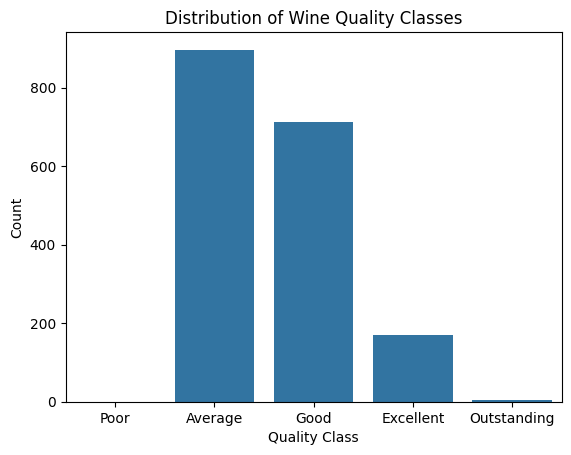

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='quality_class', data=df3, order=["Poor", "Average", "Good", "Excellent", "Outstanding"])
plt.title("Distribution of Wine Quality Classes")
plt.xlabel("Quality Class")
plt.ylabel("Count")
plt.show()

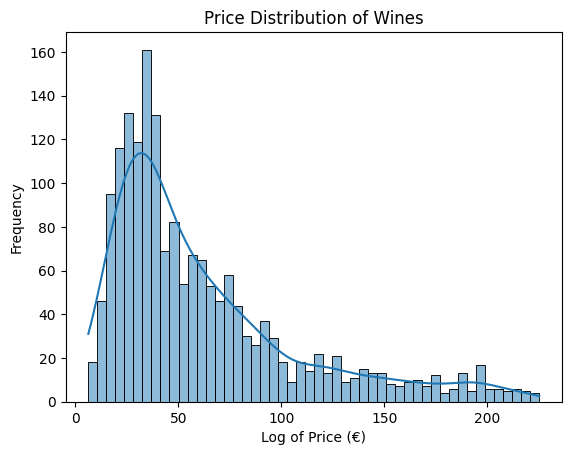

In [18]:
sns.histplot(df3['price'], kde=True, bins=50)
plt.title("Price Distribution of Wines")
plt.xlabel("Log of Price (€)")
plt.ylabel("Frequency")
plt.show()


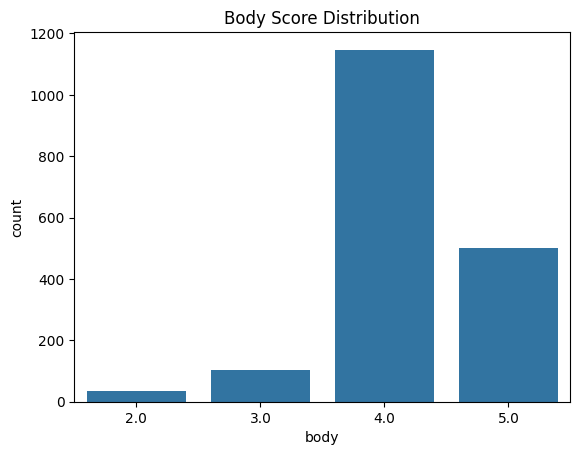

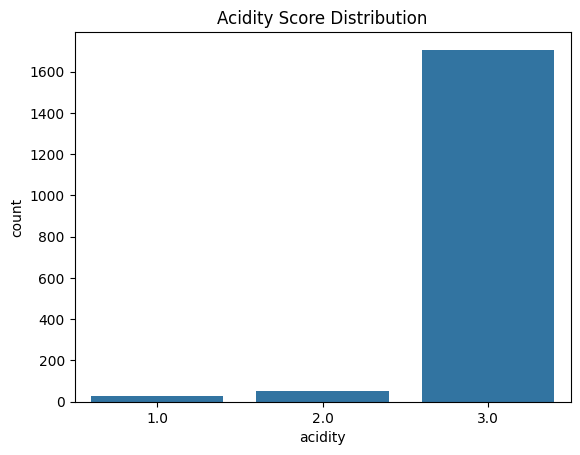

In [19]:
sns.countplot(x='body', data=df3)
plt.title("Body Score Distribution")
plt.show()
sns.countplot(x='acidity', data=df3)
plt.title("Acidity Score Distribution")
plt.show()

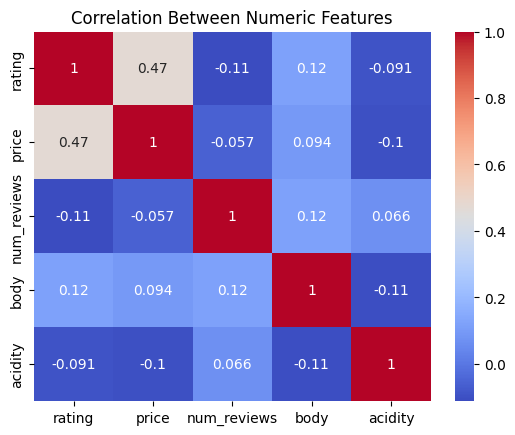

In [20]:
numeric_cols = ['rating', 'price', 'num_reviews', 'body', 'acidity']
corr = df3[numeric_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Between Numeric Features")
plt.show()

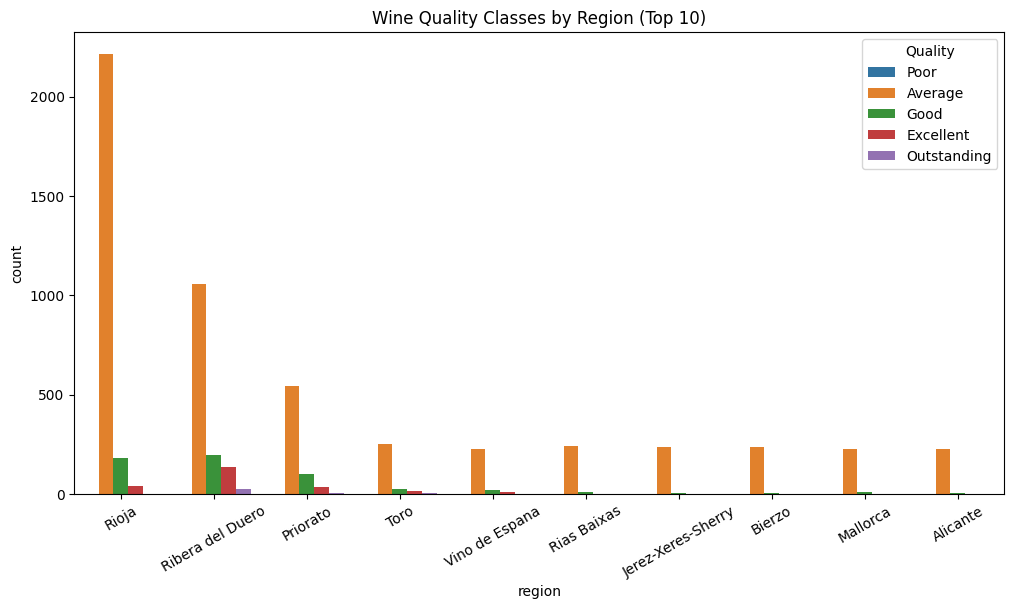

In [21]:
top_regions = df_copy['region'].value_counts().nlargest(10).index
df_region_top = df_copy[df_copy['region'].isin(top_regions)]

plt.figure(figsize=(12, 6))
sns.countplot(data=df_region_top, x='region', hue='quality_class',
              order=top_regions, hue_order=["Poor", "Average", "Good", "Excellent", "Outstanding"])
plt.title("Wine Quality Classes by Region (Top 10)")
plt.xticks(rotation=30)
plt.legend(title="Quality")
plt.show()

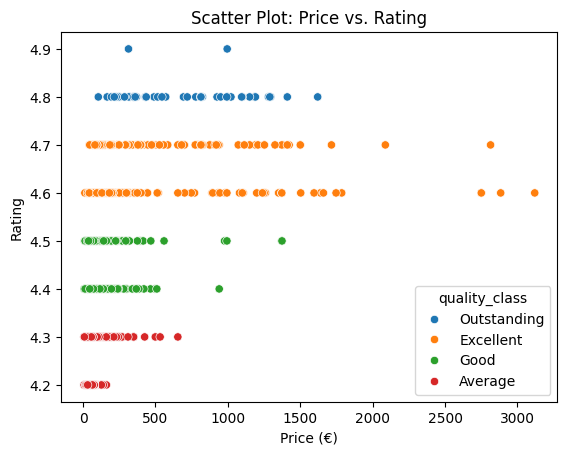

In [22]:
sns.scatterplot(x='price', y='rating', hue='quality_class',data=df_copy)
plt.title("Scatter Plot: Price vs. Rating")
plt.xlabel("Price (€)")
plt.ylabel("Rating")
plt.show()


#MODELLING

#Decision Tree Classifier Baseline Model

In [23]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
# X = features, y = labels
# Identify any remaining non-numeric columns that are not target variables
non_numeric_cols = df3.select_dtypes(include='object').columns
# Drop any remaining object columns from the features, ensuring not to drop the target
cols_to_drop_from_X = ['quality_class', 'quality_label'] + list(non_numeric_cols)
X = df3.drop(columns=cols_to_drop_from_X, axis=1, errors='ignore') # drop target and any remaining object columns

y = df3['quality_label']  # encoded labels

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

# Initialize model with default settings
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Predict
y_pred_dt = dt_model.predict(X_test)

# Evaluate
print("Decision Tree Classifier:\n")
print(classification_report(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))


Decision Tree Classifier:

              precision    recall  f1-score   support

           1       1.00      1.00      1.00       178
           2       1.00      1.00      1.00       151
           3       1.00      1.00      1.00        28

    accuracy                           1.00       357
   macro avg       1.00      1.00      1.00       357
weighted avg       1.00      1.00      1.00       357

Confusion Matrix:
 [[178   0   0]
 [  0 151   0]
 [  0   0  28]]


#Streamlit

In [28]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
# X = features, y = labels
# Identify any remaining non-numeric columns that are not target variables
non_numeric_cols = df3.select_dtypes(include='object').columns
# Drop any remaining object columns from the features, ensuring not to drop the target
cols_to_drop_from_X = ['quality_class', 'quality_label'] + list(non_numeric_cols)
X = df3.drop(columns=cols_to_drop_from_X, axis=1, errors='ignore') # drop target and any remaining object columns

y = df3['quality_label']  # encoded labels

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

# Initialize model with default settings
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Predict
y_pred_dt = dt_model.predict(X_test)

# Evaluate
print("Decision Tree Classifier:\n")
print(classification_report(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))

Decision Tree Classifier:

              precision    recall  f1-score   support

           1       1.00      1.00      1.00       178
           2       1.00      1.00      1.00       151
           3       1.00      1.00      1.00        28

    accuracy                           1.00       357
   macro avg       1.00      1.00      1.00       357
weighted avg       1.00      1.00      1.00       357

Confusion Matrix:
 [[178   0   0]
 [  0 151   0]
 [  0   0  28]]


In [32]:
import pickle

# Specify the filename
filename = '/content/drive/MyDrive/Seep 2025/ML_PROJECT_CLASSIFICATION_Baseline.pkl'

# Save the model to the file
pickle.dump(dt_model, open(filename, 'wb'))

print(f"Model exported successfully to {filename}")

Model exported successfully to /content/drive/MyDrive/Seep 2025/ML_PROJECT_CLASSIFICATION_Baseline.pkl
